# Data Visualization in Python with Matplotlib, Seaborn, and Streamlit

## General Objective
- Learn how to create effective data visualizations using Matplotlib and Seaborn.
- Build a simple web application with Streamlit.
- Upload the project to GitHub to share or deploy it.

> **LAB 4.1** — updated version of `LAB_4.ipynb`. Same content, but every cell runs
> end-to-end on current library versions (pandas 3.x / seaborn 0.13+ / matplotlib 3.10+)
> with no errors and no deprecation warnings.

| Objective                         | Data Type                              | Recommended Chart Type                      |
|----------------------------------|----------------------------------------|---------------------------------------------|
| Distribution of a variable       | Continuous/Discrete Numerical          | Histogram, KDE, Boxplot                     |
| Compare categories               | Categorical vs. Numerical              | Boxplot, Violinplot, Barplot                |
| Compare values by category       | Nominal Categorical vs. Numerical      | Barplot, Countplot                          |
| Time trends                      | Date + Numerical Variable              | Line plot                                   |
| Correlation between two variables| Two Numerical Variables                | Scatter plot, Heatmap (for many variables)  |
| Cross between two categoricals   | Two Categorical Variables              | Heatmap, Countplot with hue                 |

## 0. Setup

Install the dependencies once (uncomment if needed). `statsmodels` is optional: it is
only used by the robust regression at the end of the notebook.

In [1]:
# !pip install pandas numpy matplotlib seaborn streamlit statsmodels pyreadstat

In [2]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# statsmodels is optional (needed only for `robust=True` in sns.lmplot)
try:
    import statsmodels.api as sm  # noqa: F401
    HAS_STATSMODELS = True
except ImportError:
    HAS_STATSMODELS = False

sns.set_theme(style="darkgrid")

print("pandas    ", pd.__version__)
print("numpy     ", np.__version__)
print("seaborn   ", sns.__version__)
print("statsmodels available:", HAS_STATSMODELS)

pandas     3.0.1
numpy      2.4.3
seaborn    0.13.2
statsmodels available: False


## 1. Loading the data

Datasets transformed into Latin characters. The following commands should be used in STATA:

```stata
cd "....\documents"
unicode analyze enaho.dta
unicode encoding set "latin1"
unicode translate enaho.dta
```

### The following database includes ENAHO modules (200, 300 and 500) for the period 2011 - 2019

- Module 200: Household Member Characteristics
- Module 300: Education
- Module 500: Employment and Income

In [3]:
print("Current working directory:", os.getcwd())

Current working directory: C:\Users\Jean Pool\Documents\GitHub\Data-Science-Python\Labs\Python_Notebooks\LAB4


The path below is resolved instead of hard-coded, so the notebook works whether
`enaho.dta` sits next to it or in the repository-level `data/` folder.

In [4]:
CANDIDATES = [
    Path("enaho.dta"),                 # next to this notebook
    Path("../../../data/enaho.dta"),   # repository-level data folder
    Path("data/enaho.dta"),
]

data_path = next((p for p in CANDIDATES if p.exists()), None)
if data_path is None:
    raise FileNotFoundError(
        "enaho.dta not found. Looked in: " + ", ".join(str(p.resolve()) for p in CANDIDATES)
    )

print("Reading:", data_path.resolve())
enaho = pd.read_stata(data_path)
enaho.shape

Reading: C:\Users\Jean Pool\Documents\GitHub\Data-Science-Python\Labs\Python_Notebooks\LAB4\enaho.dta


(160772, 105)

In [5]:
enaho.head()

,year,conglome,vivienda,hogar,ubigeo,codperso,dominio,estrato,panel,p203,...,acumulado,estud,educa,d_edu,exper,exper_2,tenure_2,edad_2,jefe,ubigeo_2
0,2011,0061,077,11,010701,04,selva,"de 4,001 a 10,000 viviendas",2.011006e+14,hijo/hija,...,6.0,5.0,11.0,Secundaria completa,2.0,4.0,NaN,361.0,familiar,010000
1,2011,0110,112,11,010705,05,selva,Área de empadronamiento rural - aer compuesto,2.011011e+14,hijo/hija,...,6.0,5.0,11.0,Secundaria completa,3.0,9.0,9.0,400.0,familiar,010000
2,2011,0090,076,11,010205,03,selva,Área de empadronamiento rural - aer compuesto,2.011009e+14,nieto,...,6.0,5.0,11.0,Secundaria completa,5.0,25.0,36.0,484.0,familiar,010000
3,2011,0118,080,11,010401,03,selva,Área de empadronamiento rural - aer simple,2.011012e+14,hijo/hija,...,6.0,5.0,11.0,Secundaria completa,6.0,36.0,NaN,529.0,familiar,010000
4,2011,3408,066,11,010402,03,selva,Área de empadronamiento rural - aer compuesto,2.011341e+14,hijo/hija,...,6.0,5.0,11.0,Secundaria completa,3.0,9.0,0.0,400.0,familiar,010000


In [6]:
enaho['empresa'].head()

0             NaN
1    microempresa
2    microempresa
3             NaN
4    gran empresa
Name: empresa, dtype: category
Categories (4, str): ['microempresa' < 'pequeña empresa' < 'mediana empresa' < 'gran empresa']

## 2. Quantities

This type of graph shows the levels of variables. Also, these graphs show the variables
according to categories or classifications.

### Number of companies classified by number of workers hired

- Microbusinesses (< 10 workers)
- Small businesses (10-20 workers)
- Medium businesses (21-100 workers)
- Big businesses (> 100 workers)

Why do many examples use `fig, ax = plt.subplots()` in Matplotlib?
<https://stackoverflow.com/questions/34162443/why-do-many-examples-use-fig-ax-plt-subplots-in-matplotlib-pyplot-python>

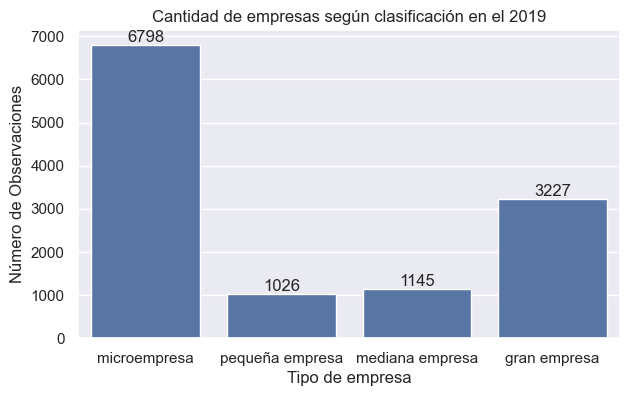

In [7]:
base_2019 = enaho[enaho['year'] == "2019"]

sns.set_theme(style="darkgrid")
fig, ax = plt.subplots(figsize=(7, 4))

sns.countplot(x="empresa", data=base_2019, ax=ax)

# Label each bar with its height
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2., height + 0.1,
            f'{height:.0f}', ha='center', va='bottom')

ax.set_title('Cantidad de empresas según clasificación en el 2019')
ax.set_xlabel('Tipo de empresa')
ax.set_ylabel('Número de Observaciones')
plt.show()

##### Horizontal countplot in a single color (red)

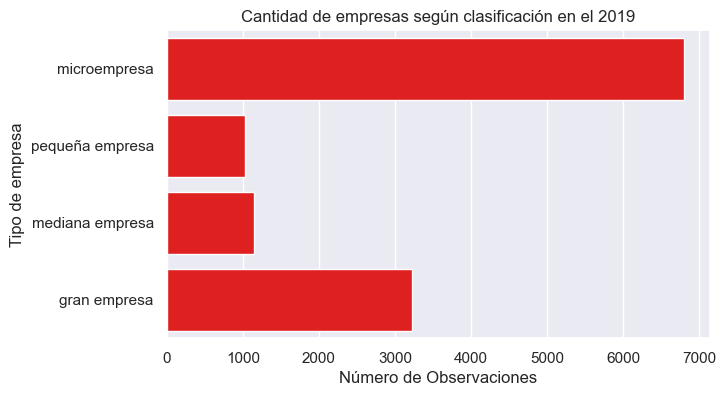

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))

sns.countplot(y="empresa", data=base_2019, color="red", ax=ax)

ax.set_title('Cantidad de empresas según clasificación en el 2019')
ax.set_xlabel('Número de Observaciones')
ax.set_ylabel('Tipo de empresa')
plt.show()

### Evolution of businesses in the period 2017-2019

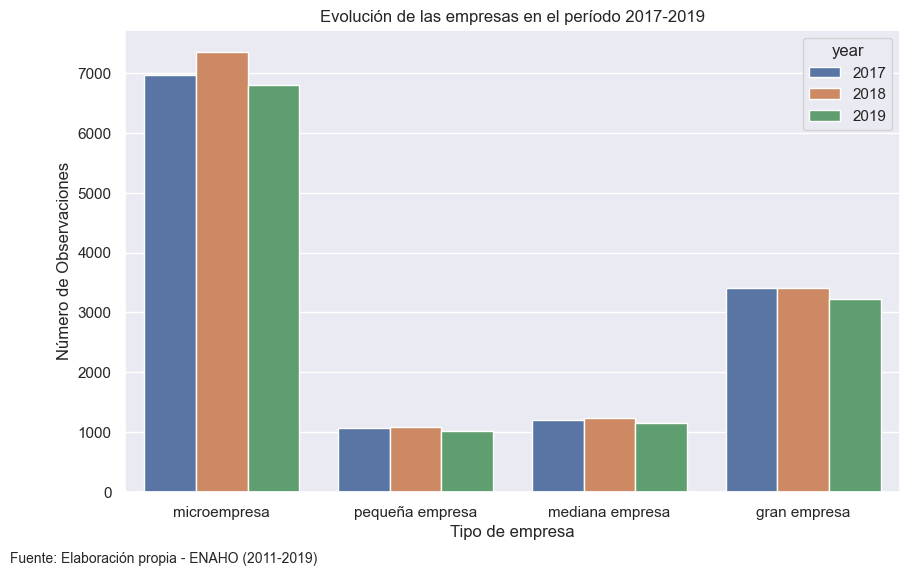

In [9]:
base2 = enaho[enaho['year'] > "2016"]

fig, ax = plt.subplots(figsize=(10, 6))

# hue: variable decomposition
sns.countplot(x="empresa", hue="year", linewidth=1, data=base2, ax=ax)

ax.set_title('Evolución de las empresas en el período 2017-2019')
ax.set_xlabel('Tipo de empresa')
ax.set_ylabel('Número de Observaciones')

txt = "Fuente: Elaboración propia - ENAHO (2011-2019)"
plt.figtext(0.01, 0.01, txt, wrap=True, horizontalalignment='left', va="top", fontsize=10)
plt.show()

### Number of companies by strata (urbano / rural) and evolution by year

- `hue` = split into groups **inside** the same axes
- `col` = create a **new panel** per group

In [10]:
base2['area'].head()

103666    Urbana
103667     Rural
103668    Urbana
103669    Urbana
103670    Urbana
Name: area, dtype: category
Categories (2, str): ['Rural' < 'Urbana']

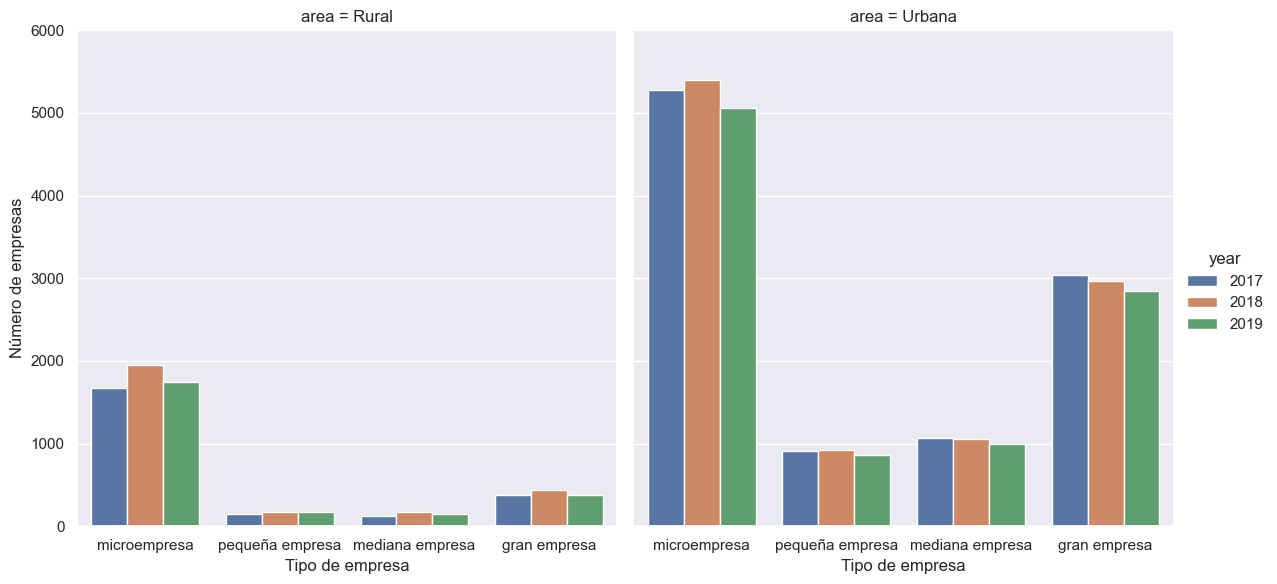

In [11]:
ag = sns.catplot(x="empresa", hue="year", col="area", data=base2,
                 kind="count", height=6, aspect=1)

(ag.set_axis_labels("Tipo de empresa", "Número de empresas")
   .set(ylim=(0, 6000))
   .despine(left=True))
plt.show()

#### Number of businesses by strata — stacked bar plot

In [12]:
enaho['conglome'].head()

0    0061
1    0110
2    0090
3    0118
4    3408
Name: conglome, dtype: str

In [13]:
enaho[enaho['year'] == "2019"].groupby(['empresa', 'area'], observed=True).size().reset_index(name='num_firms')

,empresa,area,num_firms
0,microempresa,Rural,1742
1,microempresa,Urbana,5056
2,pequeña empresa,Rural,169
3,pequeña empresa,Urbana,857
4,mediana empresa,Rural,145
5,mediana empresa,Urbana,1000
6,gran empresa,Rural,381
7,gran empresa,Urbana,2846


In [14]:
# Count businesses by strata using groupby (similar to `collapse` in Stata)
base_2 = (enaho[enaho['year'] == "2019"]
          .groupby(['empresa', 'area'], observed=True)
          .size()
          .reset_index(name='num_firms'))
base_2

,empresa,area,num_firms
0,microempresa,Rural,1742
1,microempresa,Urbana,5056
2,pequeña empresa,Rural,169
3,pequeña empresa,Urbana,857
4,mediana empresa,Rural,145
5,mediana empresa,Urbana,1000
6,gran empresa,Rural,381
7,gran empresa,Urbana,2846


In [15]:
# Reshape to wide format so the bars can be stacked
base_3 = base_2.pivot(index='empresa', columns='area', values='num_firms')
base_3

area,Rural,Urbana
empresa,,
microempresa,1742,5056
pequeña empresa,169,857
mediana empresa,145,1000
gran empresa,381,2846


In [16]:
base_3.columns

CategoricalIndex(['Rural', 'Urbana'], categories=['Rural', 'Urbana'], ordered=True, dtype='category', name='area')

In [17]:
base_3_2 = base_3[["Urbana", "Rural"]].copy()
base_3_2

area,Urbana,Rural
empresa,,
microempresa,5056,1742
pequeña empresa,857,169
mediana empresa,1000,145
gran empresa,2846,381


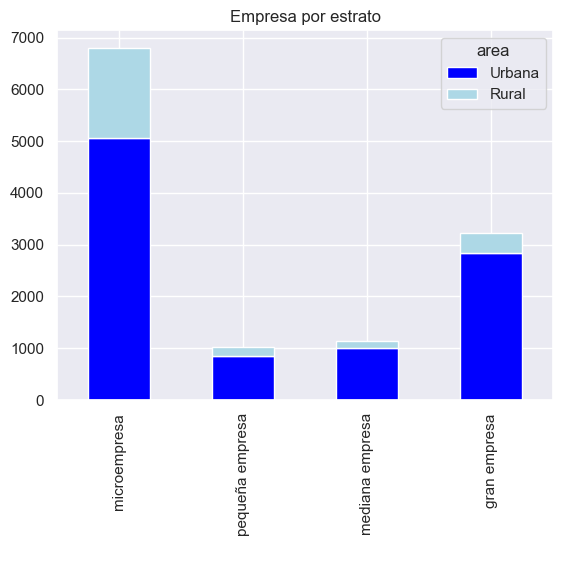

In [18]:
base_3_2.plot(kind='bar', stacked=True, title='Empresa por estrato',
              color=['blue', 'lightblue'])
plt.xlabel(' ')
plt.show()

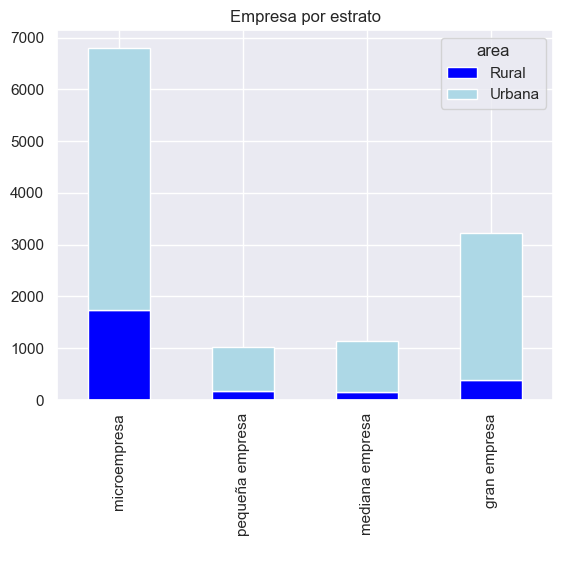

In [19]:
base_3.plot(kind='bar', stacked=True, title='Empresa por estrato',
            color=['blue', 'lightblue'])
plt.xlabel(' ')
plt.show()

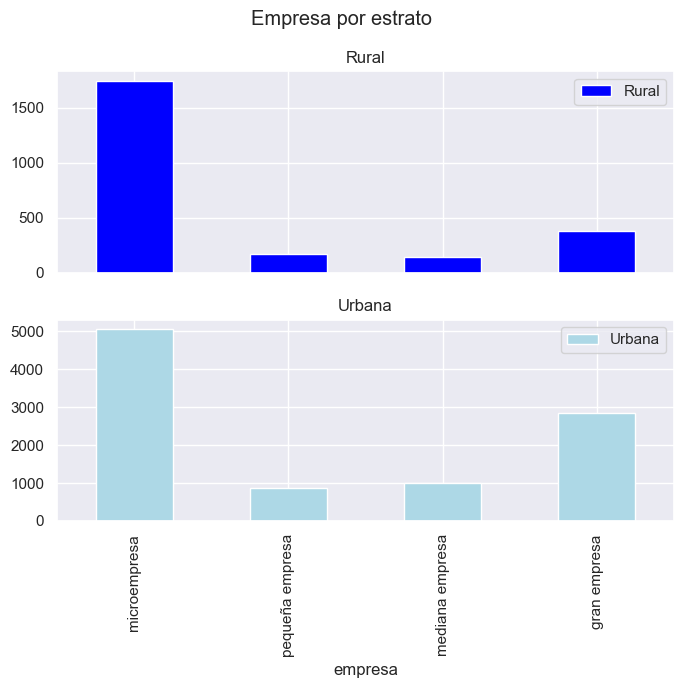

In [20]:
base_3.plot(kind='bar', rot=90, subplots=True, color=['blue', 'lightblue'],
            title='Empresa por estrato', figsize=(7, 7))
plt.tight_layout()
plt.show()

## 3. Proportions

Understandable plots to show categorical variables. Use these plots to explain the share
of each category.

### Pie chart

First, collapse the dataframe to count the categories of a variable.

In [21]:
base = enaho.groupby('empresa', observed=True).size()
base

empresa
microempresa       58002
pequeña empresa     9306
mediana empresa    10304
gran empresa       29642
dtype: int64

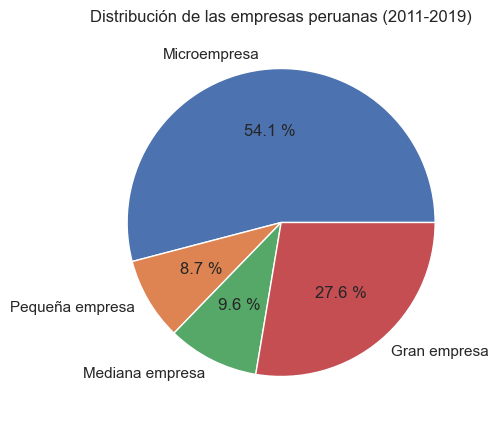

In [22]:
labels = ['Microempresa', 'Pequeña empresa', 'Mediana empresa', 'Gran empresa']

plt.figure(figsize=(5, 5))
plt.pie(base.values, labels=labels, autopct='%.1f %%')
plt.title('Distribución de las empresas peruanas (2011-2019)')
plt.show()

In [23]:
enaho['labor'].head()

0                                                  NaN
1                              Ocupaciones elementales
2    Trabajo en actividades agrícolas, selvicultura...
3                                                  NaN
4                Trabajadores de ventas y en servicios
Name: labor, dtype: category
Categories (9, str): ['Ocupaciones elementales' < 'Administradores' < 'Profesionales y fuerzas armadas' < 'Técnicos y similares' ... 'Trabajadores de ventas y en servicios' < 'Trabajo en actividades agrícolas, selvicultur... < 'Trabajo en artesanía y afines' < 'Operadores de planta y maquinaria']

In [24]:
base = enaho.groupby('labor', observed=True).size()
base

labor
Ocupaciones elementales                                   25556
Administradores                                           11310
Profesionales y fuerzas armadas                            1958
Técnicos y similares                                      12414
Asistentes administrativos                                14423
Trabajadores de ventas y en servicios                     18691
Trabajo en actividades agrícolas, selvicultura y pesca     5224
Trabajo en artesanía y afines                              8648
Operadores de planta y maquinaria                         11794
dtype: int64

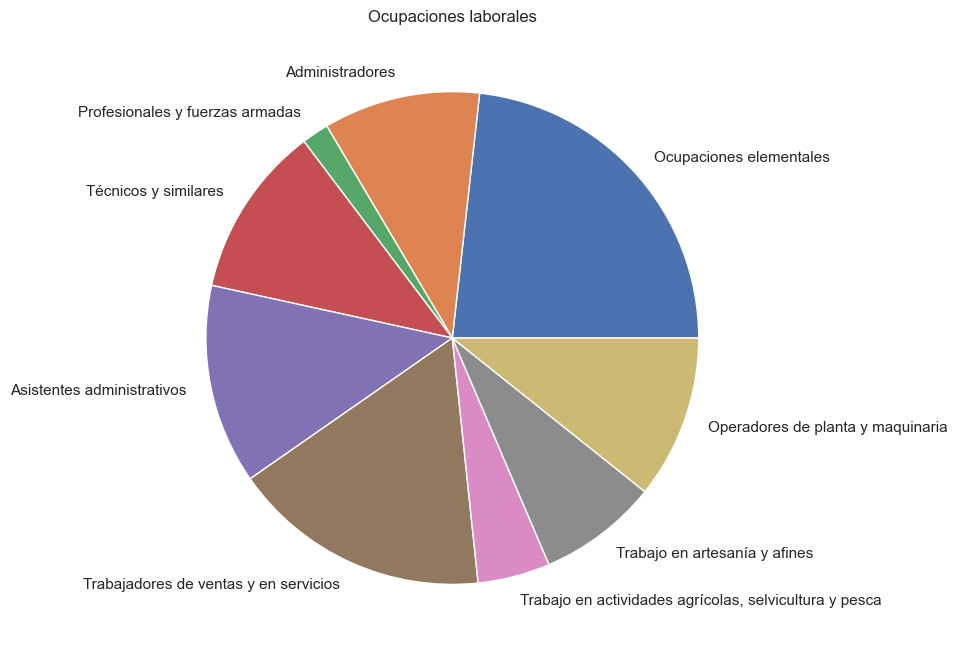

In [25]:
base.plot(kind='pie', figsize=(8, 8))
plt.title("Ocupaciones laborales")
plt.ylabel("")
plt.show()

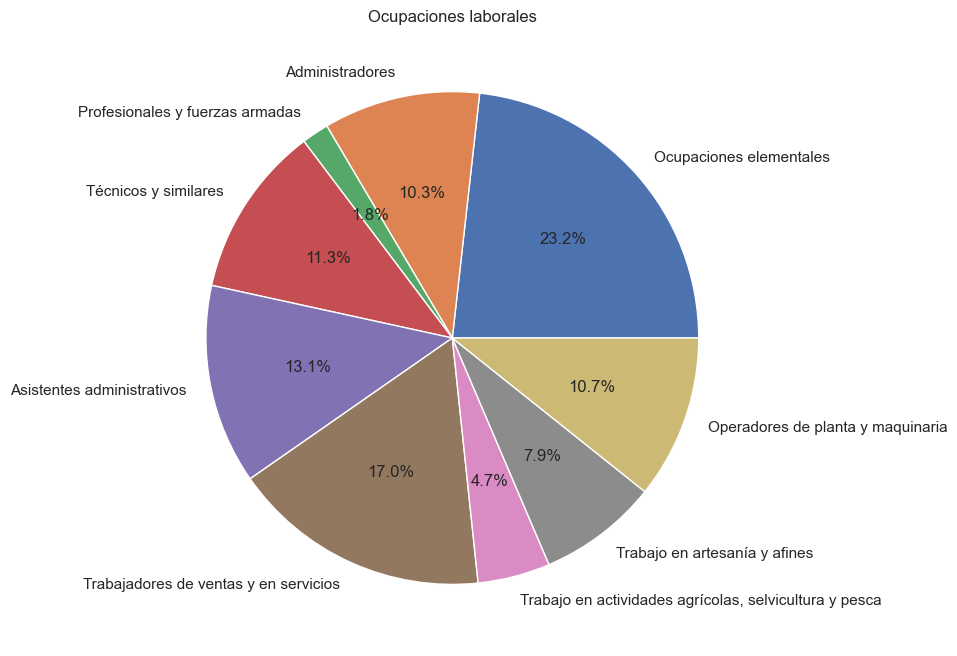

In [26]:
base.plot(kind='pie', figsize=(8, 8), autopct='%1.1f%%')  # add the percentage format
plt.title("Ocupaciones laborales")
plt.ylabel("")
plt.show()

### Donut chart

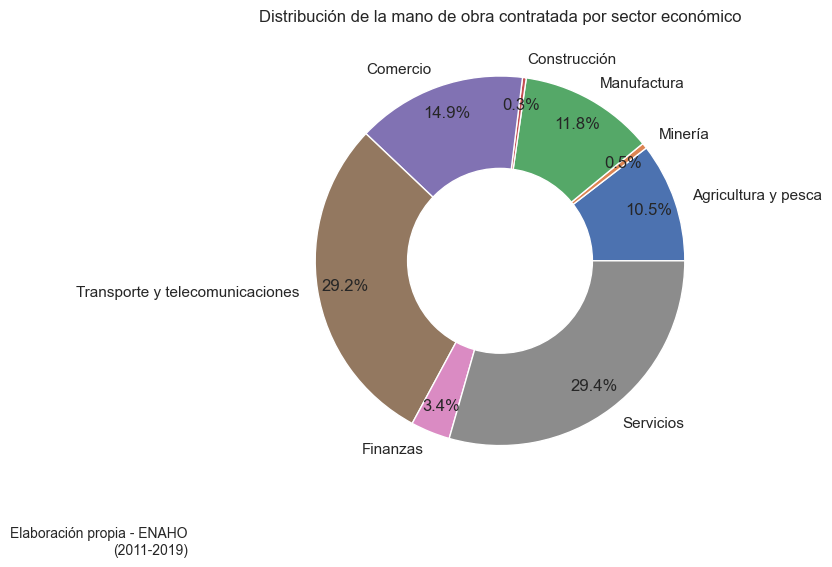

In [27]:
base2_sector = enaho.groupby('sector', observed=True).size()

labels = ['Agricultura y pesca', 'Minería', 'Manufactura', 'Construcción', 'Comercio',
          'Transporte y telecomunicaciones', 'Finanzas', 'Servicios']

plt.figure(figsize=(10, 6))
plt.pie(base2_sector.values, labels=labels, autopct='%1.1f%%', pctdistance=0.85)

# Hollow centre turns the pie into a donut
center_circle = plt.Circle((0, 0), 0.50, fc='white')
plt.gcf().gca().add_artist(center_circle)

plt.title('Distribución de la mano de obra contratada por sector económico')

txt = "Elaboración propia - ENAHO (2011-2019)"
plt.figtext(0.2, 0.01, txt, wrap=True, horizontalalignment='right', fontsize=10)
plt.show()

## 4. Distributions

Distribution plots visually assess the distribution of sample data by comparing the
empirical distribution of the data with the theoretical values expected from a
specified distribution.

In [28]:
# Filter the database to 2019
base4 = enaho[enaho['year'] == "2019"]
base4.shape

(18045, 105)

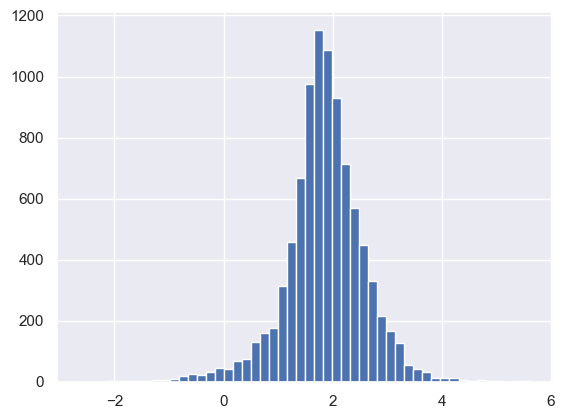

In [29]:
base4['l_salario'].hist(bins=50)
plt.show()

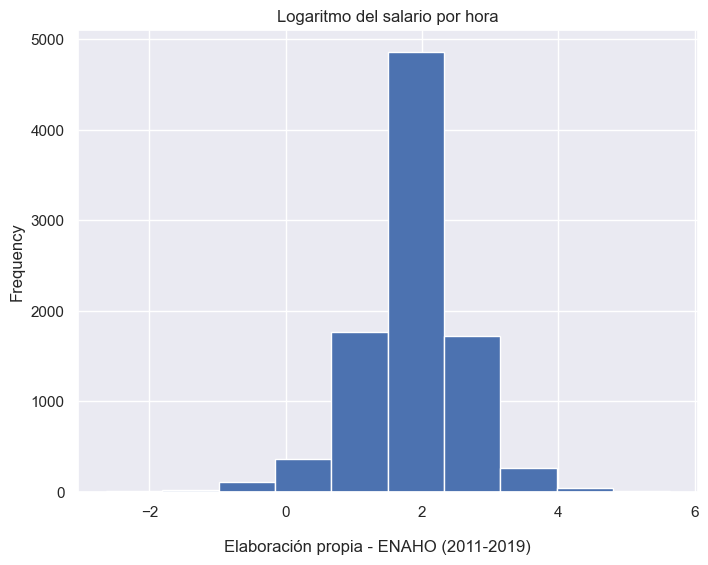

In [30]:
base4['l_salario'].plot(kind='hist', bins=10, figsize=(8, 6))
plt.title('Logaritmo del salario por hora')

txt = "Elaboración propia - ENAHO (2011-2019)"
plt.figtext(0.5, 0.01, txt, wrap=True, horizontalalignment='center', fontsize=12)
plt.show()

### Reducing intervals

Frequency distribution with a smaller interval (lower relative frequency). Therefore,
the height of each bar accounts for a smaller amount.

In [31]:
base4['l_salario'].describe()

count    9171.000000
mean        1.858420
std         0.734179
min        -2.636912
25%         1.504606
50%         1.850513
75%         2.262777
max         5.633581
Name: l_salario, dtype: float64

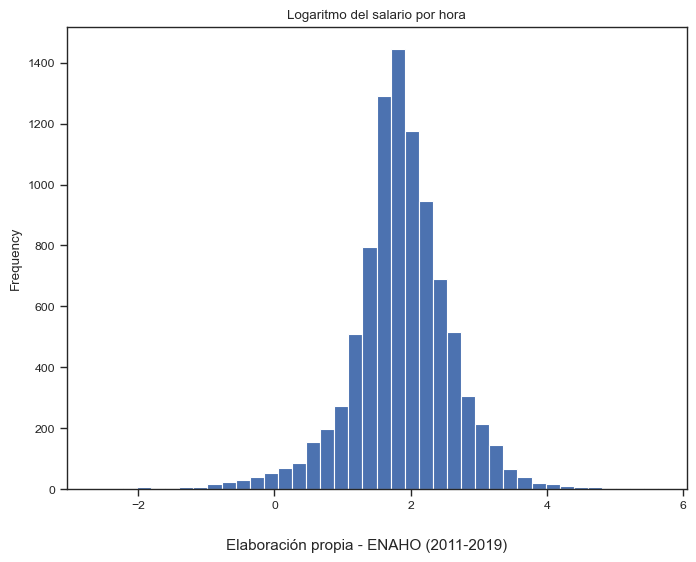

In [32]:
sns.set_theme(context='paper', style='ticks')

base4['l_salario'].plot(kind='hist', bins=40, figsize=(8, 6))
plt.title('Logaritmo del salario por hora')

txt = "Elaboración propia - ENAHO (2011-2019)"
plt.figtext(0.5, 0.01, txt, wrap=True, horizontalalignment='center', fontsize=11)
plt.show()

### Multiple histograms

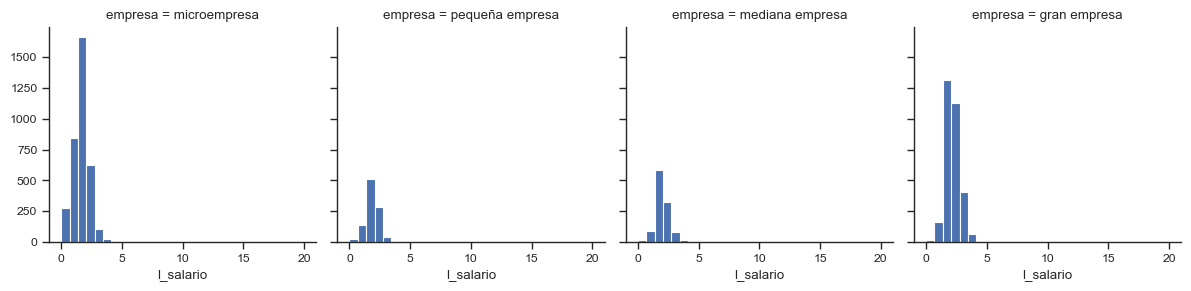

In [33]:
figure1 = sns.FacetGrid(base4, col="empresa", margin_titles=True)
figure1.map(plt.hist, 'l_salario', bins=np.linspace(0, 20, 30))
plt.show()

##### Real salary per hour density

The distribution does not resemble a standard normal. The information is concentrated in
lower values and there are some observations with high values.

> `sns.distplot` was removed from seaborn — `sns.histplot(..., kde=True)` is the
> modern replacement.

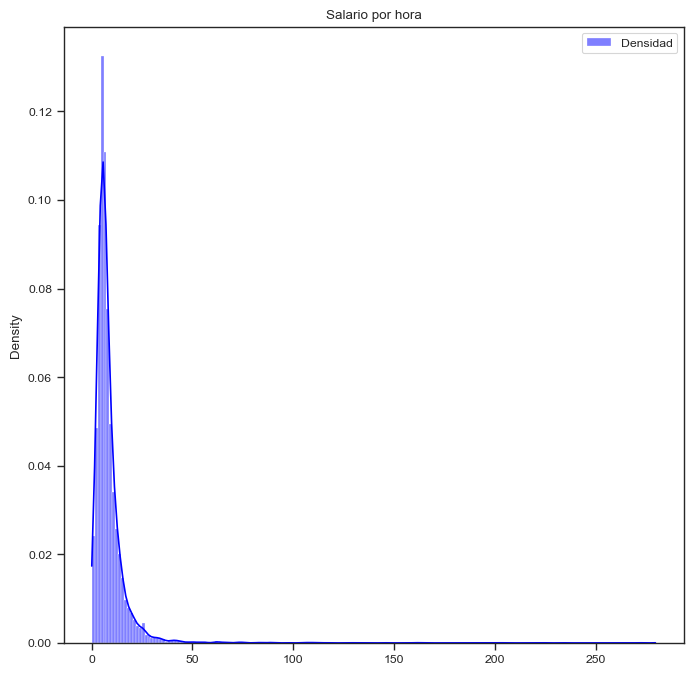

In [34]:
plt.figure(figsize=(8, 8))

sns.histplot(base4['salario'], kde=True, label="Densidad", color='blue', stat='density')
plt.title('Salario por hora')
plt.xlabel(' ')
plt.legend()
plt.show()

### Logarithm of the real hourly wage

This allows correcting the asymmetry presented by the original data.

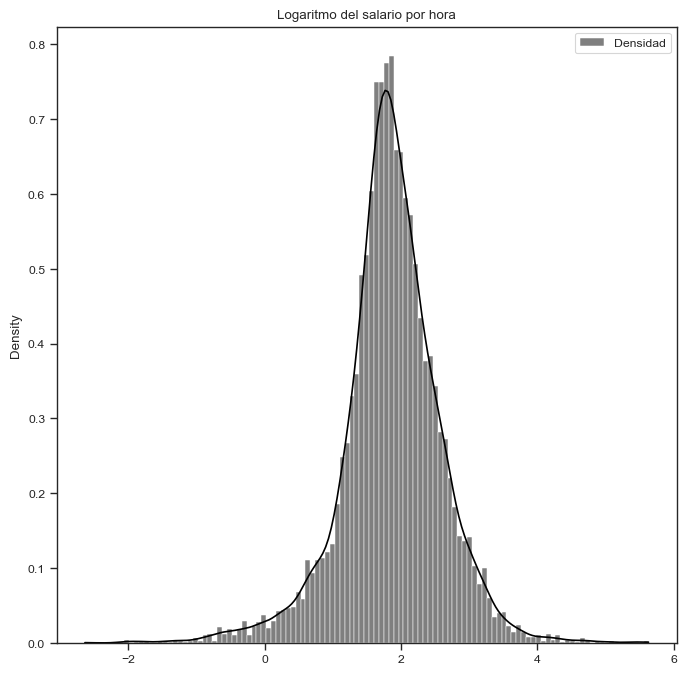

In [35]:
plt.figure(figsize=(8, 8))

sns.histplot(base4['l_salario'], kde=True, label="Densidad", color='black', stat='density')
plt.title('Logaritmo del salario por hora')
plt.xlabel(' ')
plt.legend()
plt.show()

#### Real salaries for three sectors (Construction, Commerce and Mining)

> `shade=True` was replaced by `fill=True` in seaborn 0.11+.

In [36]:
base4['sector'].cat.categories

Index(['agricultura, selvicultura y pesca', 'minería',
       'Manufactura y servicios públcios', 'Construcción',
       'Comercio, hoteles y restaurantes',
       'Transporte, comunicaciones y alamacenamiento',
       'Finanzas, seguro y bienes raíces',
       'Servicios persnales, sociales y comunales'],
      dtype='str')

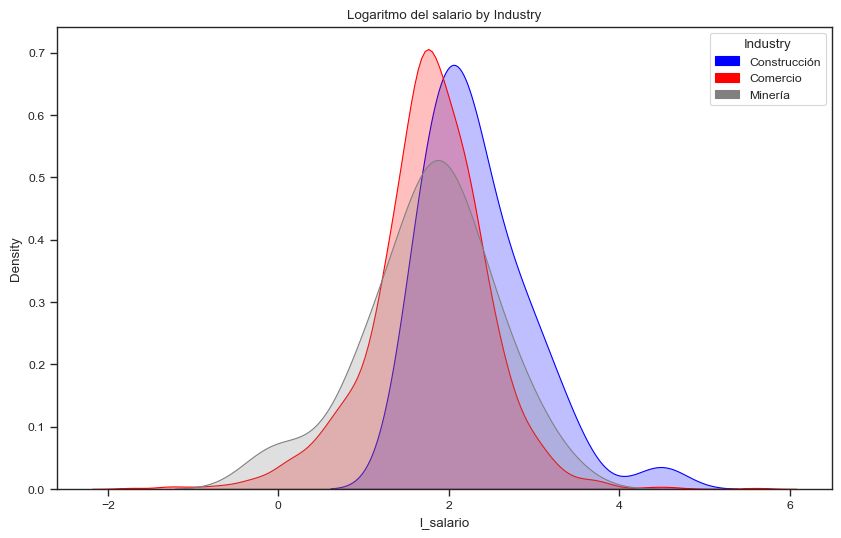

In [37]:
plt.figure(figsize=(10, 6))

sns.kdeplot(base4.l_salario[base4.sector == 'Construcción'],
            label='Construcción', fill=True, color="blue")
sns.kdeplot(base4.l_salario[base4.sector == 'Comercio, hoteles y restaurantes'],
            label='Comercio, hoteles y restaurantes', fill=True, color="red")
sns.kdeplot(base4.l_salario[base4.sector == 'minería'],
            label='Minería', fill=True, color="gray")

plt.title('Logaritmo del salario by Industry')

handles = [mpatches.Patch(color='blue', label='Construcción'),
           mpatches.Patch(color='red', label='Comercio'),
           mpatches.Patch(color='gray', label='Minería')]
plt.legend(handles=handles, title='Industry')
plt.show()

# The construction sector shows certain stochastic dominance over mining and commerce.

### Labor occupations and real salary per hour densities

A `for` loop is used to include, in the same graph, the density function of hourly wages
for different occupations.

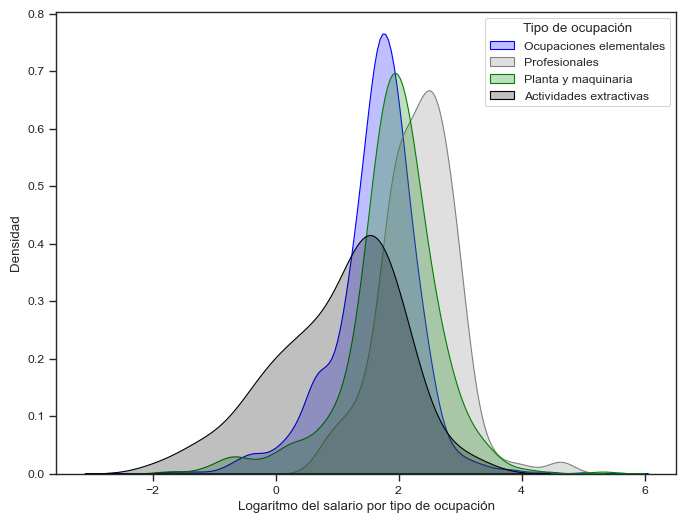

In [38]:
fig, ax = plt.subplots(figsize=(8, 6))

ocupaciones = ['Ocupaciones elementales',
               'Profesionales y fuerzas armadas',
               'Operadores de planta y maquinaria',
               'Trabajo en actividades agrícolas, selvicultura y pesca']

nombres = ['Ocupaciones elementales', 'Profesionales',
           'Planta y maquinaria', 'Actividades extractivas']

colores = ['blue', 'gray', 'green', 'black']

for a, b, c in zip(ocupaciones, nombres, colores):
    sns.kdeplot(base4.l_salario[base4.labor == a], label=b, fill=True, color=c, ax=ax)

ax.set_xlabel('Logaritmo del salario por tipo de ocupación')
ax.set_ylabel('Densidad')
ax.legend(title='Tipo de ocupación')
plt.show()

# Two relevant findings: stochastic dominance of the salary of professionals, and
# concentration at lower salary levels in the primary sector.

### Box plot: real salary and education

> Passing `palette` without a `hue` is deprecated — assign `hue` and hide the legend.

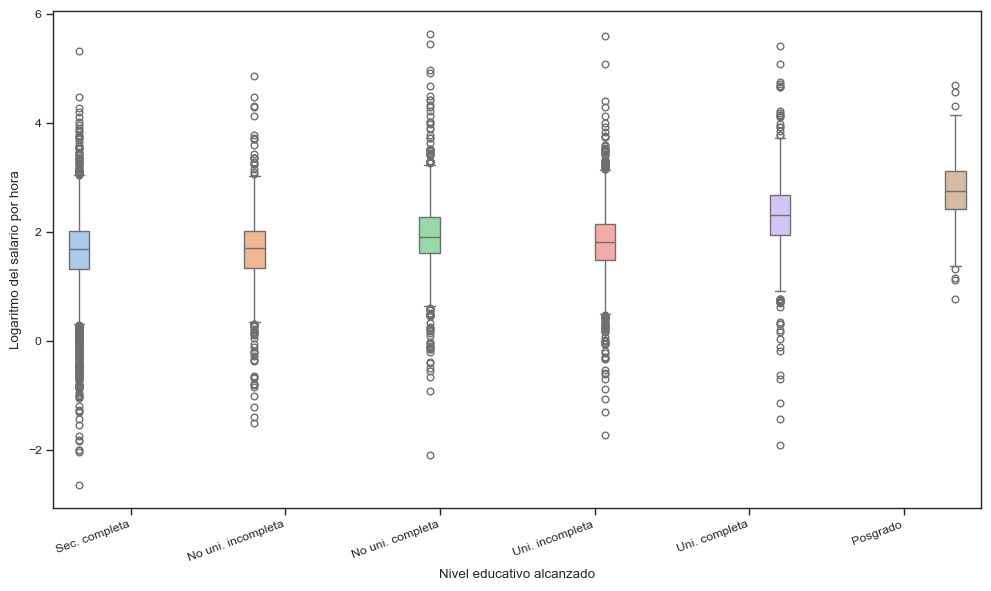

In [39]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(x="educ", y="l_salario", data=base_2019,
            hue="educ", palette="pastel", legend=False, ax=ax)

ax.set_xlabel('Nivel educativo alcanzado')
ax.set_ylabel('Logaritmo del salario por hora')

etiquetas = ["Sec. completa", "No uni. incompleta", "No uni. completa",
             "Uni. incompleta", "Uni. completa", "Posgrado"]
ax.set_xticks(range(len(etiquetas)))
ax.set_xticklabels(etiquetas, rotation=20, ha='right')
plt.tight_layout()
plt.show()

# Real wage quartiles increase with the educational level.
# Lower salary dispersion at the postgraduate level.

## 5. Relationships

Charts used for both time series and cross-sectional data. These graphs allow us to
establish certain evidence of correlation or relationships between variables.

### Scatter plot

First, a random sample is drawn from the original database. Subsequently, a scatter plot
is presented between the hourly wage (logarithm) and the non-labor monthly income (logarithm).

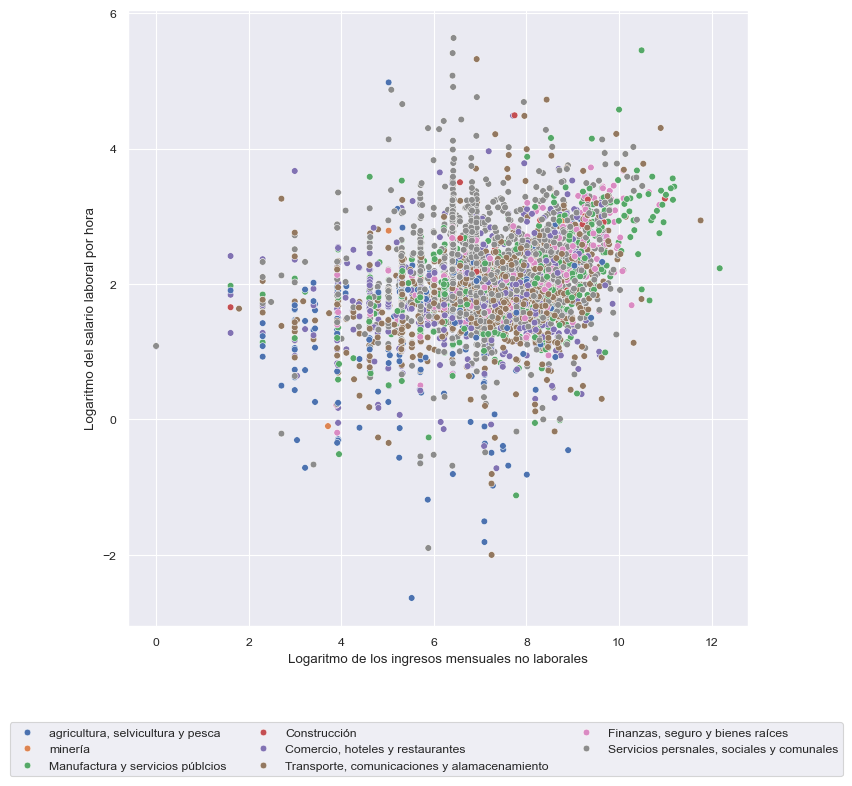

In [40]:
# Full sample
sns.set_theme(context='paper')
plt.figure(figsize=(8, 8))

plot = sns.scatterplot(data=base4, x="l_n_labor", y="l_salario", hue="sector", palette="deep")

plt.xlabel('Logaritmo de los ingresos mensuales no laborales')
plt.ylabel('Logaritmo del salario laboral por hora')

# By default the legend sits inside the axes; move it outside.
# bbox_to_anchor: box location — ncol: number of legend columns
plot.legend(loc='center left', bbox_to_anchor=(-0.2, -0.2), ncol=3)
plt.show()

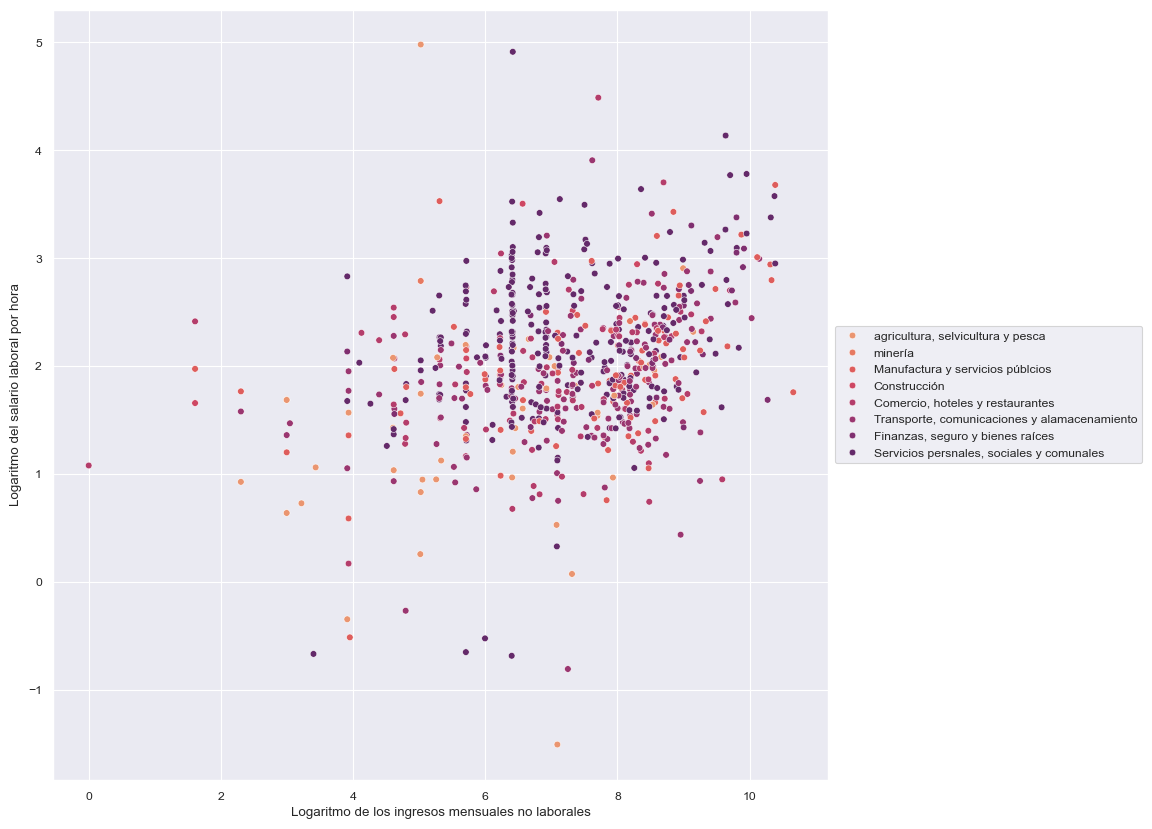

In [41]:
# Random sample, n = 3000 (seeded so the notebook is reproducible)
base5 = base4.sample(n=3000, random_state=42)

sns.set_theme(context='paper')
plt.figure(figsize=(10, 10))

plot = sns.scatterplot(data=base5, x="l_n_labor", y="l_salario", hue="sector", palette="flare")

plt.xlabel('Logaritmo de los ingresos mensuales no laborales')
plt.ylabel('Logaritmo del salario laboral por hora')

plot.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=1)
plt.show()

#### Regression: real salary per hour and non-labor income by strata

- `s` = the marker size in points**2
- `linewidths` = the linewidth of the marker edges

`robust=True` requires `statsmodels`; the cell falls back to ordinary least squares when
it is not installed, so it never breaks the run.

statsmodels not installed -> plotted an OLS fit instead of a robust fit


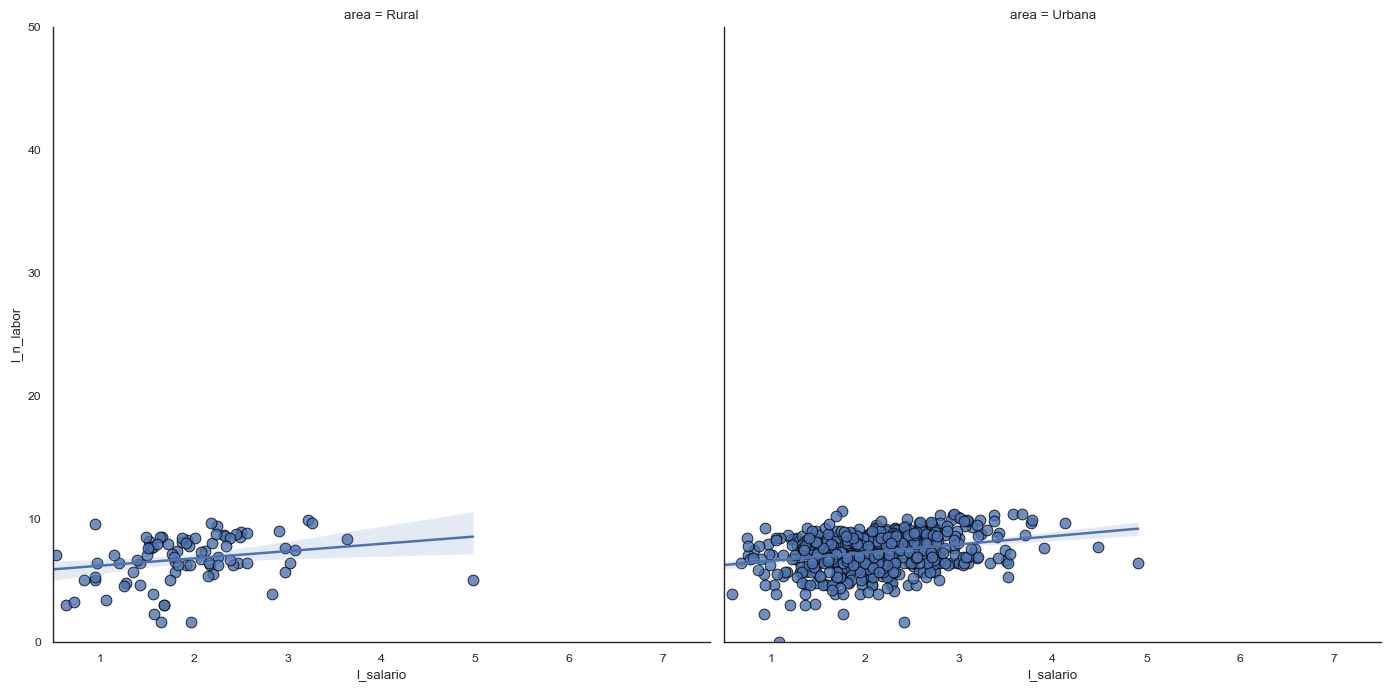

In [42]:
sns.set_style("white")

gridobj = sns.lmplot(x="l_salario", y="l_n_labor",
                     data=base5,
                     height=7,
                     robust=HAS_STATSMODELS,
                     col="area",
                     scatter_kws=dict(s=60, linewidths=0.7, edgecolors='black'))

gridobj.set(xlim=(0.5, 7.5), ylim=(0, 50))
if not HAS_STATSMODELS:
    print("statsmodels not installed -> plotted an OLS fit instead of a robust fit")
plt.show()

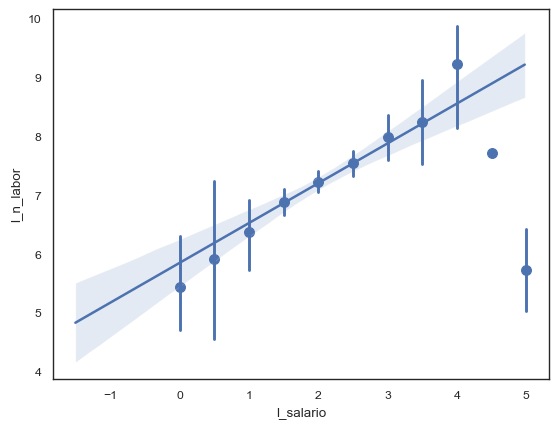

In [43]:
sns.regplot(data=base5, x="l_salario", y="l_n_labor",
            x_bins=np.arange(0, 7, 0.5), order=1)
plt.show()

## 6. Streamlit

Streamlit apps are meant to be executed with `streamlit run`, not inside a notebook —
calling `st.*` in a kernel only produces "missing ScriptRunContext" warnings.

The cell below writes a small app to `app.py`. Run it from a terminal with:

```bash
streamlit run app.py
```

In [44]:
%%writefile app.py
import streamlit as st

st.title("Mi Primera Aplicación con Streamlit")
st.write("¡Hola mundo!")

# Widget interactivo
nombre = st.text_input("Escribe tu nombre")
if nombre:
    st.write(f"Hola, {nombre}!")

Writing app.py


In [45]:
print(Path("app.py").read_text(encoding="utf-8"))

import streamlit as st

st.title("Mi Primera Aplicación con Streamlit")
st.write("¡Hola mundo!")

# Widget interactivo
nombre = st.text_input("Escribe tu nombre")
if nombre:
    st.write(f"Hola, {nombre}!")



## Summary of changes vs. `LAB_4.ipynb`

| Issue in LAB_4 | Fix in LAB_4.1 |
|---|---|
| `enaho['conglome']` had a stray leading space → `IndentationError` | indentation removed |
| `sns.lmplot(robust=True)` crashed without `statsmodels` | falls back to OLS via `HAS_STATSMODELS` |
| `sns.distplot` (removed in seaborn 0.14) | `sns.histplot(..., kde=True)` |
| `shade=True` in `kdeplot` (error in 0.14) | `fill=True` |
| `palette` without `hue` in `boxplot` | `hue="educ", legend=False` |
| `set_xticklabels` without fixed ticks | `set_xticks` first |
| `groupby` on categoricals | explicit `observed=True` |
| Hard-coded `../../../data/enaho.dta` | path resolved from a candidate list |
| `import streamlit` executed in the kernel | written to `app.py` with `%%writefile` |
| `.sample(n=3000)` unseeded | `random_state=42` for reproducibility |